In [1]:
using CSV
using DataFrames
using Plots


In [10]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,142.697284,85872500,85872500,1.992478,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,2,143.458309,85872500,85872500,1.951813,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,3,143.575852,85872500,85872500,1.968659,1,2.8308235056082117e-13
sachdeva_star_700_350,solved,4,144.106494,85872500,85872500,1.958897,1,2.8308235056082117e-13
weighted_boundary_chimera_10000000_1,solved,1,95.433169,61539879,61539879,604.752528,133,8.495717436016712e-9
weighted_boundary_chimera_10000000_1,solved,2,227.017731,113383056,113383056,541.757309,83,8.96180126516271e-9
weighted_boundary_chimera_10000000_1,solved,3,633.517851,208055930,208055930,615.519123,66,9.832873138549388e-9
weighted_boundary_chimera_10000000_1,solved,4,1955.347071,373979449,373979449,721.913263,48,9.571148080745356e-9
weighted_chimera_10000000_1,solved,1,95.566794,62174860,62174860,877.886321,171,4.4219559295345556e-8
weighted_chimera_10000000_1,solved,2,231.810621,114823463,114823463,1357.346843,192,3.553624341352973e-8
weighted_chimera_10000000_1,solved,3,612.946781,211104362,211104362,1997.105265,200,1.4172851185339062e-8
weighted_chimera_10000000_1,solved,4,2029.592371,379997514,379997514,3054.188414,191,1.415112812823452e-8
anisotropic_poisson_grid_200000000_0,solved,1,56.291965,199726506,199726506,524.038918,125,9.54113932730775e-9
anisotropic_poisson_grid_200000000_0,solved,2,87.804221,341588716,341588716,582.813892,99,9.680231964168813e-9
anisotropic_poisson_grid_200000000_0,solved,3,179.806316,624754071,624754071,566.239103,70,9.95388237691913e-9
anisotropic_poisson_grid_200000000_0,solved,4,311.464598,1019920306,1019920306,580.462606,54,9.535295281346532e-9
high_contrast_poisson_grid_200000000_32,solved,1,62.593446,199726506,199726506,854.009206,190,1.7207813483854688e-8
high_contrast_poisson_grid_200000000_32,solved,2,101.405605,341588716,341588716,1028.828502,171,8.634517739405257e-9
high_contrast_poisson_grid_200000000_32,solved,3,206.207737,624754071,624754071,1043.549682,128,9.194500511552302e-9
high_contrast_poisson_grid_200000000_32,solved,4,361.28619,1019920306,1019920306,1080.071109,99,9.795838151810155e-9
McRae/ecology2,solved,1,1.155917,3995993,3995993,16.878266,200,4.17481518346197e-8
McRae/ecology2,solved,2,1.513937,4992991,4992991,18.807988,187,2.988018156741727e-8
McRae/ecology2,solved,3,2.083955,6985986,6985986,23.350632,200,1.1943915811464105e-8
McRae/ecology2,solved,4,2.638145,8976982,8976982,22.286845,157,9.445352520264857e-9
McRae/ecology1,solved,1,1.140832,3995998,3995998,17.295737,175,3.2438568105345797e-5
McRae/ecology1,solved,2,1.526925,4993000,4993000,18.947924,187,3.084271356303493e-5
McRae/ecology1,solved,3,2.06534,6986004,6986004,23.158541,134,3.089961556978005e-5
McRae/ecology1,solved,4,2.606305,8977010,8977010,27.133891,105,3.084225831456567e-5
"""

# Read the CSV data from the in-memory string
df1 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ilu(k)" for each row
df1[!, :method] = fill("ilu(k)", nrow(df1))

# Display the resulting DataFrame
println(df1)

28×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo      nnz_hi      solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64       Int64       Float64          Int64      Float64         String 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1             142.697      85872500    85872500          1.99248          1     2.83082e-13  ilu(k)
   2 │ sachdeva_star_700_350              solved         2             143.458      85872500    85872500          1.95181          1     2.83082e-13  ilu(k)
   3 │ sachdeva_star_700_350              solved         3             143.576      85872500    85872500          1.96866          1     2.83082e-13  ilu(k)
   4 │ sachdeva_star_700_350           

In [12]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,48.54916501045227,85875711,85875711,323.7032699584961,416,9.51747543192303e-9
sachdeva_star_700_350,solved,2,84.32447290420532,85881229,85881229,35.305160999298096,46,7.614393454743692e-9
anisotropic_poisson_grid_200000000_0,solved,1,86.74100089073181,257836193,257836193,227.5739710330963,40,7.316452231679001e-9
anisotropic_poisson_grid_200000000_0,solved,2,175.91168308258057,347217850,347217850,228.07864713668823,26,5.750001059283358e-9
high_contrast_poisson_grid_200000000_32,solved,1,89.13559794425964,268471798,268471798,342.4774339199066,59,8.392473774243765e-9
high_contrast_poisson_grid_200000000_32,solved,2,182.49084210395813,371370700,371370700,395.121630191803,44,9.672145143074953e-9
weighted_boundary_chimera_10000000_1,solved,1,39.742156982421875,69956110,69956110,128.24494290351868,37,6.66998661460035e-9
weighted_boundary_chimera_10000000_1,solved,2,65.17965888977051,92663274,92663274,111.7504448890686,26,5.906417979326677e-9
weighted_chimera_10000000_1,solved,1,45.11845111846924,74273403,74273403,97.33402299880981,26,8.476494563547517e-9
weighted_chimera_10000000_1,solved,2,73.27236294746399,100430951,100430951,85.34627890586853,20,7.503605045100883e-9
McRae/ecology2,solved,1,1.1913738250732422,5406140,5406140,3.261389970779419,41,7.083323073643435e-9
McRae/ecology2,solved,2,2.146501064300537,6429666,6429666,2.556785821914673,25,7.1941774282262224e-9
McRae/ecology1,solved,1,1.1838629245758057,5407779,5407779,3.200061082839966,41,8.786756813883156e-9
McRae/ecology1,solved,2,2.1748909950256348,6431605,6431605,2.411324977874756,25,8.335065014412723e-9
"""

# Read the CSV data from an in-memory string
df2 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df2[!, :method] = fill("ac(k)", nrow(df2))

# Display the resulting DataFrame
println(df2)

14×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo     nnz_hi     solution_time_s  pcg_iters  relative_error  method 
     │ String                             String7  Int64    Float64               Int64      Int64      Float64          Int64      Float64         String 
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1              48.5492    85875711   85875711        323.703          416      9.51748e-9  ac(k)
   2 │ sachdeva_star_700_350              solved         2              84.3245    85881229   85881229         35.3052          46      7.61439e-9  ac(k)
   3 │ anisotropic_poisson_grid_2000000…  solved         1              86.741    257836193  257836193        227.574           40      7.31645e-9  ac(k)
   4 │ anisotropic_poisson_grid_2000000…  solved      

In [19]:
data = """
name,status,k_param,factorisation_time_s,nnz_lo,nnz_hi,solution_time_s,pcg_iters,relative_error
sachdeva_star_700_350,solved,1,20.65277886390686,85872850,85872850,16.575321912765503,20,6.605876077490706e-9
anisotropic_poisson_grid_200000000_0,solved,1,122.33768486976624,788940014,788940014,317.89750695228577,44,4.1399221403544936e-9
high_contrast_poisson_grid_200000000_32,solved,1,117.036367893219,836602925,836602925,655.9620571136475,98,9.161425643738163e-9
weighted_boundary_chimera_10000000_1,solved,1,17.20728302001953,82200068,82200068,304.3475260734558,105,9.93387631690475e-9
weighted_chimera_10000000_1,solved,1,19.862016916275024,94174084,94174084,454.29780888557434,150,9.627256773197422e-9
McRae/ecology2,solved,1,0.6768250465393066,9916680,9916680,4.455230951309204,44,9.796520523154947e-9
McRae/ecology1,solved,1,0.6488730907440186,9864065,9864065,4.195208787918091,42,9.774821126404627e-9
"""

# Read the CSV data from an in-memory string
df3 = CSV.read(IOBuffer(data), DataFrame)

# Add a new column "method" with the constant value "ac(k)"
df3[!, :method] = fill("ac(1,given)", nrow(df3))

# Display the resulting DataFrame
println(df3)

7×10 DataFrame
 Row │ name                               status   k_param  factorisation_time_s  nnz_lo     nnz_hi     solution_time_s  pcg_iters  relative_error  method      
     │ String                             String7  Int64    Float64               Int64      Int64      Float64          Int64      Float64         String      
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350              solved         1             20.6528     85872850   85872850         16.5753          20      6.60588e-9  ac(1,given)
   2 │ anisotropic_poisson_grid_2000000…  solved         1            122.338     788940014  788940014        317.898           44      4.13992e-9  ac(1,given)
   3 │ high_contrast_poisson_grid_20000…  solved         1            117.036     836602925  836602925        655.962           98      9.16143e-9  ac(1,given)
   4 │ weighted_bounda

In [21]:
Tin = df0
Tiluk = df1
Tack = df2
TackGiven = df3

# 1. Concatenate Tiluk and Tack vertically, then join with Tin on "name"
T = innerjoin(Tin, vcat(Tiluk, Tack, TackGiven), on = :name)

# 2. Print a summary of the joined DataFrame (rough equivalent to T.glimpse())
println("DataFrame Summary:")
describe(T)
println()

# 3. Select only the desired columns
T = select(T, [:name, :n, :nnz, :method, :k_param, :status, :nnz_lo, :nnz_hi, :pcg_iters, :relative_error])

# 4. Create a new column "fillin" computed as nnz_lo divided by nnz (elementwise)
T.fillin = T.nnz_lo ./ T.nnz

# 5. Sort the DataFrame by "name", "method", and "k_param"
T = sort(T, [:name, :method, :k_param])

# 6. Display the full DataFrame (all rows and columns)
show(T, allcols=true, allrows=true)

DataFrame Summary:

49×11 DataFrame
 Row │ name                               n         nnz        method       k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin   
     │ String                             Int64     Int64      String       Int64    String7  Int64       Int64       Int64      Float64         Float64  
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ McRae/ecology1                      1000000    4996000  ac(1,given)        1  solved      9864065     9864065         42     9.77482e-9   1.97439
   2 │ McRae/ecology1                      1000000    4996000  ac(k)              1  solved      5407779     5407779         41     8.78676e-9   1.08242
   3 │ McRae/ecology1                      1000000    4996000  ac(k)              2  solved      6431605     6431605         25     8.33507e-9   1.28735
   4 │ McRae/ecology1                   

7×11 DataFrame
 Row │ name                               n        nnz       method       k_param  status   nnz_lo     nnz_hi     pcg_iters  relative_error  fillin  
     │ String                             Int64    Int64     String       Int64    String7  Int64      Int64      Int64      Float64         Float64 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ weighted_boundary_chimera_100000…  9953703  54191549  ac(1,given)        1  solved    82200068   82200068        105      9.93388e-9  1.51684
   2 │ weighted_boundary_chimera_100000…  9953703  54191549  ac(k)              1  solved    69956110   69956110         37      6.66999e-9  1.2909
   3 │ weighted_boundary_chimera_100000…  9953703  54191549  ac(k)              2  solved    92663274   92663274         26      5.90642e-9  1.70992
   4 │ weighted_boundary_chimera_100000…  9953703  54191549  ilu(k)             1  solved

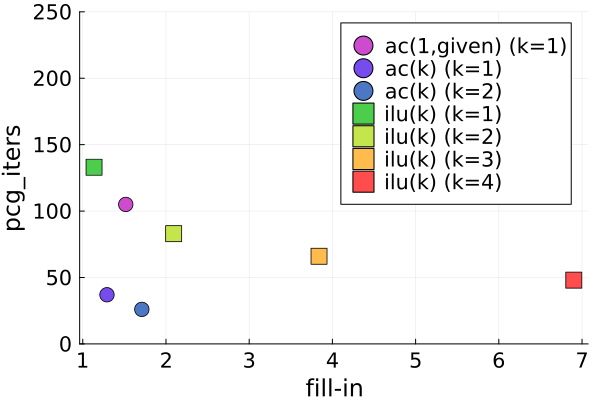

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wb.png"

In [22]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "weighted_boundary_chimera_10000000_1", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_wb.png")

7×11 DataFrame
 Row │ name                         n         nnz       method       k_param  status   nnz_lo     nnz_hi     pcg_iters  relative_error  fillin  
     │ String                       Int64     Int64     String       Int64    String7  Int64      Int64      Int64      Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ weighted_chimera_10000000_1  10000000  54649712  ac(1,given)        1  solved    94174084   94174084        150      9.62726e-9  1.72323
   2 │ weighted_chimera_10000000_1  10000000  54649712  ac(k)              1  solved    74273403   74273403         26      8.47649e-9  1.35908
   3 │ weighted_chimera_10000000_1  10000000  54649712  ac(k)              2  solved   100430951  100430951         20      7.50361e-9  1.83772
   4 │ weighted_chimera_10000000_1  10000000  54649712  ilu(k)             1  solved    62174860   62174860        171

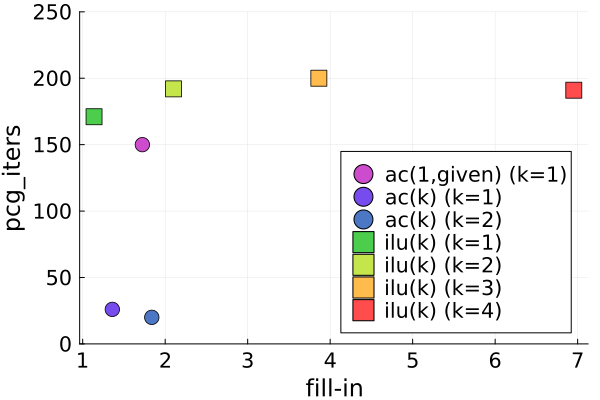

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_wc.png"

In [23]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "weighted_chimera_10000000_1", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_wc.png")

7×11 DataFrame
 Row │ name                               n         nnz        method       k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin  
     │ String                             Int64     Int64      String       Int64    String7  Int64       Int64       Int64      Float64         Float64 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(1,given)        1  solved    788940014   788940014         44      4.13992e-9  3.94457
   2 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)              1  solved    257836193   257836193         40      7.31645e-9  1.28914
   3 │ anisotropic_poisson_grid_2000000…  28652616  200006496  ac(k)              2  solved    347217850   347217850         26      5.75e-9     1.73603
   4 │ anisotropic_poisson_grid_2000000…  28652616  200006496  i

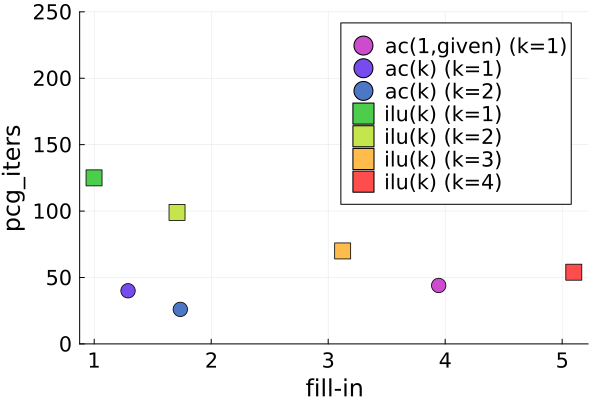

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_an.png"

In [24]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "anisotropic_poisson_grid_200000000_0", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_an.png")

7×11 DataFrame
 Row │ name                               n         nnz        method       k_param  status   nnz_lo      nnz_hi      pcg_iters  relative_error  fillin  
     │ String                             Int64     Int64      String       Int64    String7  Int64       Int64       Int64      Float64         Float64 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ high_contrast_poisson_grid_20000…  28652616  200006496  ac(1,given)        1  solved    836602925   836602925         98      9.16143e-9  4.18288
   2 │ high_contrast_poisson_grid_20000…  28652616  200006496  ac(k)              1  solved    268471798   268471798         59      8.39247e-9  1.34232
   3 │ high_contrast_poisson_grid_20000…  28652616  200006496  ac(k)              2  solved    371370700   371370700         44      9.67215e-9  1.85679
   4 │ high_contrast_poisson_grid_20000…  28652616  200006496  i

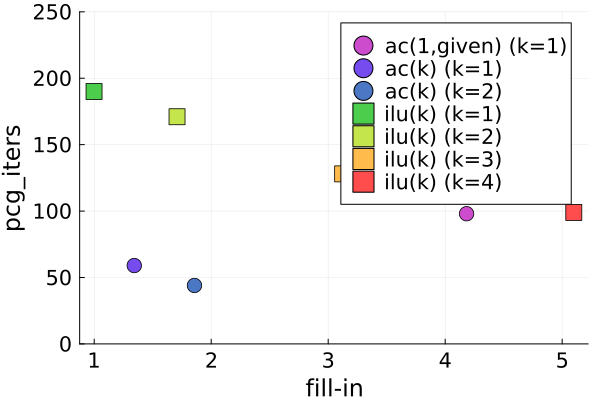

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_hc.png"

In [29]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "high_contrast_poisson_grid_200000000_32", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 250))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_hc.png")

7×11 DataFrame
 Row │ name                   n       nnz        method       k_param  status   nnz_lo    nnz_hi    pcg_iters  relative_error  fillin   
     │ String                 Int64   Int64      String       Int64    String7  Int64     Int64     Int64      Float64         Float64  
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ sachdeva_star_700_350  245001  171500701  ac(1,given)        1  solved   85872850  85872850         20     6.60588e-9   0.500714
   2 │ sachdeva_star_700_350  245001  171500701  ac(k)              1  solved   85875711  85875711        416     9.51748e-9   0.500731
   3 │ sachdeva_star_700_350  245001  171500701  ac(k)              2  solved   85881229  85881229         46     7.61439e-9   0.500763
   4 │ sachdeva_star_700_350  245001  171500701  ilu(k)             1  solved   85872500  85872500          1     2.83082e-13  0.500712
   5 │ sachdeva_star_700_350  

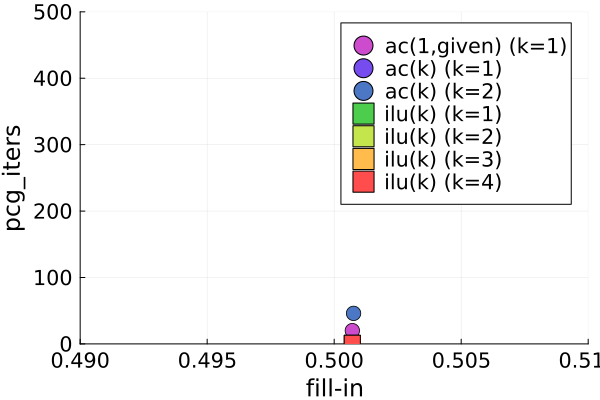

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_ss.png"

In [26]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "sachdeva_star_700_350", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 500),     # set y-axis lower limit to 0
           xlims = (0.49, 0.51)) # set x-axis 



# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_ss.png")

7×11 DataFrame
 Row │ name            n       nnz      method       k_param  status   nnz_lo   nnz_hi   pcg_iters  relative_error  fillin  
     │ String          Int64   Int64    String       Int64    String7  Int64    Int64    Int64      Float64         Float64 
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ McRae/ecology2  999999  4995991  ac(1,given)        1  solved   9916680  9916680         44      9.79652e-9  1.98493
   2 │ McRae/ecology2  999999  4995991  ac(k)              1  solved   5406140  5406140         41      7.08332e-9  1.0821
   3 │ McRae/ecology2  999999  4995991  ac(k)              2  solved   6429666  6429666         25      7.19418e-9  1.28697
   4 │ McRae/ecology2  999999  4995991  ilu(k)             1  solved   3995993  3995993        200      4.17482e-8  0.79984
   5 │ McRae/ecology2  999999  4995991  ilu(k)             2  solved   4992991  4992991        187      2.98802e-8 

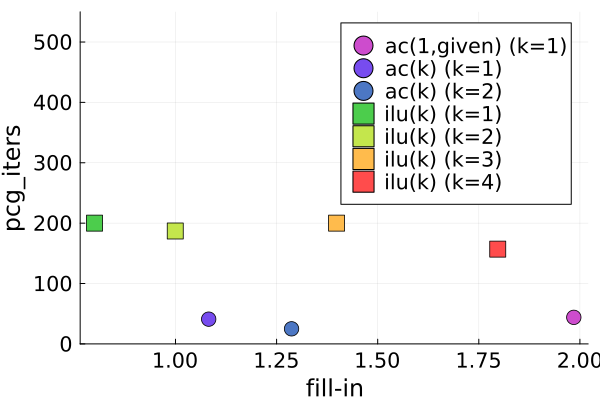

"/Users/rjkyng/Dropbox/Repos/2024-lap/SDDM2023/performance-analyses/scatter_me.png"

In [31]:
# Assume T is already defined as in previous examples

# 1. Filter the DataFrame for the specific "name"
Twb = filter(row -> row.name == "McRae/ecology2", T)

# Display the filtered DataFrame (all columns and rows)
show(Twb, allcols=true, allrows=true)

# 2. Group by :method and :k_param
grouped = groupby(Twb, [:method, :k_param])

# 3. Determine a unique color for each group using the Viridis palette
n_groups = length(grouped)
group_colors = palette(:lightrainbow, n_groups)

# 4. Initialize a blank plot with axis labels and title
plt = plot(xlabel = "fill-in", ylabel = "pcg_iters",
           xguidefont = font(16),    # larger x-axis label
           yguidefont = font(16),    # larger y-axis label
           legendfontsize = 14,      # larger legend text
           tickfont = font(14),      # larger tick labels
           ylims = (0, 550))     # set y-axis lower limit to 0

# 5. Loop over each group, set marker shape based on method, and plot with a unique color
for (i, subdf) in enumerate(grouped)
    # Construct label from method and k_param values (assumed constant per group)
    label_str = "$(subdf.method[1]) (k=$(subdf.k_param[1]))"
    
    # Choose marker shape: square for "ilu(k)" and circle otherwise
    marker_shape = (subdf.method[1] == "ilu(k)") ? :square : :circle

    # Plot the series; marker tuple: (shape, size)
    scatter!(plt, subdf.fillin, subdf.pcg_iters,
             label = label_str,
             marker = (marker_shape, 8),
             color = group_colors[i])
end


# 6. Display the plot
display(plt)

savefig(plt, "scatter_me.png")